<a href="https://colab.research.google.com/github/porfaanotamicorreo/XM_API/blob/main/upme_pronostico_generacion_lstm_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UPME — Pronóstico de generación eléctrica total (GWh) con LSTM

Este cuaderno descarga el dataset abierto de UPME **"Producción de electricidad por fuente de combustible"** (datos.gov.co, id `tq63-itzr`), calcula la generación **total mensual** del sistema (todas las fuentes sumadas) y pronostica el mes siguiente al último dato disponible con una red **LSTM** (red neuronal recurrente, Keras/TensorFlow) entrenada sobre ventanas de los últimos 12 meses.

**Cosas para tener en cuenta antes de correrlo:**

1. **El límite de "1.000 filas" del portal es solo del diálogo de exportación web**, no de la API. Aquí se pagina `/resource/tq63-itzr.json` con `$limit`/`$offset` hasta traer todo el histórico (~2.786 filas, sin token).
2. **El dataset es mensual.** El pronóstico real (LSTM) es para el mes siguiente; el estimado "semanal" de más abajo es ese pronóstico repartido proporcionalmente entre 7 días — referencia de magnitud, no un modelo independiente de variación semanal (esa variación no existe en la fuente).
3. **El mes en curso suele venir incompleto en el dataset** (UPME lo publica como acumulado parcial y lo termina de corregir después). Sin filtrar, ese último punto se ve como una caída brusca de generación que no es real, y arrastra tanto el entrenamiento del LSTM como el pronóstico. El cuaderno lo detecta y lo descarta automáticamente antes de entrenar (sección 4b).
3. **Tamaño de la serie:** son ~308 meses de historia (2000–2026), que con ventanas de 12 meses da del orden de 290 secuencias de entrenamiento. Es poco para una red neuronal (un LSTM normalmente rinde mejor con miles de secuencias) — se mitiga con dropout y *early stopping*, pero un modelo estadístico clásico (SARIMA, como en la versión anterior de este cuaderno) puede comportarse igual de bien o mejor con esta cantidad de datos. Queda como comparación posible al final.
4. **Un LSTM no da un intervalo de confianza como un modelo estadístico.** Aquí se aproxima uno con *Monte Carlo Dropout* (predicciones repetidas con dropout activo) — es una aproximación razonable, no un intervalo de confianza clásico. Además, al ser una red neuronal, los números pueden variar ligeramente entre corridas (no es 100% determinista como SARIMA).

Corre las celdas en orden.

## 1. Instalar dependencias

TensorFlow y scikit-learn ya vienen preinstalados en Colab; el `pip install` es solo por seguridad.

In [ ]:
!pip install -q tensorflow scikit-learn requests pandas matplotlib

## 2. Imports y configuración

In [ ]:
from __future__ import annotations

import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
DATASET_ID = "tq63-itzr"
BASE_URL = f"https://www.datos.gov.co/resource/{DATASET_ID}.json"

# Si vas a correr esto seguido, saca un App Token gratis en
# https://www.datos.gov.co/profile/edit/developer_settings
# y pégalo aquí (opcional para una corrida puntual):
APP_TOKEN = None  # p.ej. "abcdEFGH12345token"

LOOK_BACK = 12   # meses de historia que ve el modelo para predecir el siguiente
TEST_SIZE = 24   # meses reservados para evaluar el modelo (no se usan para entrenar el modelo final)
N_SIMULACIONES_MC = 200  # corridas de Monte Carlo Dropout para el intervalo de incertidumbre

# Paleta consistente con el resto del flujo UPME
COLOR_HIST = "#2a78d6"
COLOR_FCST = "#eb6834"
COLOR_TEST = "#1baf7a"
COLOR_GRID = "#e1e0d9"
COLOR_MUTED = "#898781"
COLOR_INK = "#0b0b0b"

## 3. Descargar el dataset completo

Pagina el endpoint de a 5.000 filas hasta que la API devuelva una página vacía. Esto evita por completo el límite de 1.000 filas del diálogo de exportación web.

In [ ]:
def descargar_dataset(page_size: int = 5000) -> pd.DataFrame:
    rows: list[dict] = []
    offset = 0
    headers = {"X-App-Token": APP_TOKEN} if APP_TOKEN else {}
    while True:
        params = {"$limit": page_size, "$offset": offset, "$order": "ano,mes"}
        resp = requests.get(BASE_URL, params=params, headers=headers, timeout=30)
        resp.raise_for_status()
        batch = resp.json()
        if not batch:
            break
        rows.extend(batch)
        if len(batch) < page_size:
            break
        offset += page_size
    return pd.DataFrame(rows)


print("Descargando dataset completo de UPME (producción por fuente)...")
df = descargar_dataset()
print(f"{len(df)} filas descargadas.")
df.head()

Descargando dataset completo de UPME (producción por fuente)...
2786 filas descargadas.


,ano,mes,fuente,promedio_mensual_gwh,maximo_gwh,minimo_gwh,generacion_total_gwh,porcentaje_participacion
0,2000,1,ACPM,1.577589611111111,2.683876,0.5307066,14.1983065,0.426629829719028
1,2000,1,AGUA,70.27965954290322,76.4053852,57.62908886,2178.66944583,65.46452386335666
2,2000,1,BAGAZO,0.2536151724137931,0.29835,0.19132,7.35484,0.2209977744043415
3,2000,1,CARBON,8.514893548387096,13.3384,4.0846,263.9617,7.931504727225402
4,2000,1,COMBUSTOLEO,1.525638977096774,2.0785226,1.02953258,47.29480829,1.421111454901806


## 4. Construir la serie mensual de generación total

Suma `generacion_total_gwh` de todas las fuentes (hidráulica, gas, carbón, viento, solar, etc.) agrupando por (año, mes) → generación total del sistema, mes a mes.

In [ ]:
def construir_serie_mensual(df: pd.DataFrame) -> pd.Series:
    df = df.copy()
    df["ano"] = df["ano"].astype(int)
    df["mes"] = df["mes"].astype(int)
    df["generacion_total_gwh"] = df["generacion_total_gwh"].astype(float)

    mensual = (
        df.groupby(["ano", "mes"], as_index=False)["generacion_total_gwh"]
        .sum()
        .rename(columns={"generacion_total_gwh": "total_gwh"})
    )
    mensual["fecha"] = pd.to_datetime(
        mensual["ano"].astype(str) + "-" + mensual["mes"].astype(str).str.zfill(2) + "-01"
    )
    mensual = mensual.sort_values("fecha").set_index("fecha")

    serie = mensual["total_gwh"].asfreq("MS")
    n_faltantes = int(serie.isna().sum())
    if n_faltantes:
        print(f"Aviso: {n_faltantes} mes(es) sin dato en la serie; se interpolan linealmente.")
        serie = serie.interpolate()
    return serie


serie = construir_serie_mensual(df)
print(f"Serie construida: {len(serie)} meses, de {serie.index[0].strftime('%B %Y')} a {serie.index[-1].strftime('%B %Y')}.")
serie.tail(12)

Serie construida: 320 meses, de January 2000 a August 2026.


,total_gwh
fecha,
2025-09-01,7125.380183
2025-10-01,7236.494852
2025-11-01,7009.227223
2025-12-01,7372.035244
2026-01-01,7277.995243
2026-02-01,6590.693107
2026-03-01,7457.060018
2026-04-01,7212.411445
2026-05-01,7656.214270


## 4b. Descartar el mes en curso si está incompleto

UPME suele publicar el mes corriente como un acumulado parcial (se termina de completar en actualizaciones posteriores del dataset), no como el total final del mes. Si se deja tal cual, ese último punto se ve como una caída brusca de generación que **no es real** — es solo que aún no se han contado todos los días del mes, y tanto el entrenamiento del LSTM como el pronóstico final quedarían distorsionados por ese punto.

Esta celda compara el último dato contra el promedio de los `ventana` meses anteriores. Si está muy por debajo (menos del `umbral` de ese promedio), lo descarta y avisa — y repite el chequeo, por si hubiera más de un mes parcial al final.

In [ ]:
def limpiar_meses_incompletos(serie: pd.Series, ventana: int = 3, umbral: float = 0.6) -> pd.Series:
    serie = serie.copy()
    while len(serie) > ventana:
        promedio_reciente = serie.iloc[-(ventana + 1):-1].mean()
        ultimo = serie.iloc[-1]
        if ultimo < umbral * promedio_reciente:
            print(
                f"Aviso: {serie.index[-1].strftime('%B %Y')} parece un mes incompleto "
                f"({ultimo:.0f} GWh vs ~{promedio_reciente:.0f} GWh promedio de los {ventana} "
                f"meses anteriores) -> se descarta de la serie."
            )
            serie = serie.iloc[:-1]
        else:
            break
    return serie


serie = limpiar_meses_incompletos(serie)
ultimo_dato = serie.index[-1]
print(f"\nÚltimo dato considerado completo: {ultimo_dato.strftime('%B %Y')} -> {serie.iloc[-1]:.1f} GWh")
print(f"Longitud de la serie: {len(serie)} meses")
serie.tail(12)

Aviso: August 2026 parece un mes incompleto (2455 GWh vs ~7548 GWh promedio de los 3 meses anteriores) -> se descarta de la serie.

Último dato considerado completo: July 2026 -> 7695.1 GWh
Longitud de la serie: 319 meses


,total_gwh
fecha,
2025-08-01,7234.140252
2025-09-01,7125.380183
2025-10-01,7236.494852
2025-11-01,7009.227223
2025-12-01,7372.035244
2026-01-01,7277.995243
2026-02-01,6590.693107
2026-03-01,7457.060018
2026-04-01,7212.411445


## 5. Preparar los datos para el LSTM

Se normaliza la serie a [0, 1] (los LSTM entrenan mejor así) y se arma con ventanas deslizantes: cada ejemplo de entrenamiento son los `LOOK_BACK` meses anteriores como entrada (X) y el mes siguiente como salida (y). Se separan los últimos `TEST_SIZE` meses como conjunto de prueba, solo para medir qué tan bien generaliza el modelo — no se usan para el pronóstico final.

In [ ]:
def crear_secuencias(valores_escalados: np.ndarray, look_back: int):
    X, y = [], []
    for i in range(len(valores_escalados) - look_back):
        X.append(valores_escalados[i:i + look_back])
        y.append(valores_escalados[i + look_back])
    X = np.array(X).reshape(-1, look_back, 1)
    y = np.array(y)
    return X, y


escalador = MinMaxScaler(feature_range=(0, 1))
valores_escalados = escalador.fit_transform(serie.values.reshape(-1, 1)).flatten()

X, y = crear_secuencias(valores_escalados, LOOK_BACK)
X_train, y_train = X[:-TEST_SIZE], y[:-TEST_SIZE]
X_test, y_test = X[-TEST_SIZE:], y[-TEST_SIZE:]

print(f"Secuencias totales: {len(X)}  |  entrenamiento: {len(X_train)}  |  prueba: {len(X_test)}")

Secuencias totales: 307  |  entrenamiento: 283  |  prueba: 24


## 6. Entrenar y evaluar el LSTM

Arquitectura simple (una capa LSTM + dropout + una capa densa) para no sobreajustar con tan pocos datos. Se entrena con *early stopping* sobre el conjunto de prueba, y se evalúa el error en GWh (no en la escala normalizada) para que el número tenga sentido físico.

In [ ]:
def construir_modelo(look_back: int, unidades: int = 50, dropout: float = 0.2) -> tf.keras.Model:
    modelo = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(look_back, 1)),
        tf.keras.layers.LSTM(unidades),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1),
    ])
    modelo.compile(optimizer="adam", loss="mse")
    return modelo


modelo_eval = construir_modelo(LOOK_BACK)
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)

historia = modelo_eval.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=200, batch_size=16, verbose=0, callbacks=[early_stop],
)
epocas_optimas = len(historia.history["loss"])
print(f"Entrenamiento detenido en la época {epocas_optimas} (early stopping).")

pred_test_escalado = modelo_eval.predict(X_test, verbose=0).flatten()
pred_test = escalador.inverse_transform(pred_test_escalado.reshape(-1, 1)).flatten()
real_test = escalador.inverse_transform(y_test.reshape(-1, 1)).flatten()

mae = mean_absolute_error(real_test, pred_test)
rmse = float(np.sqrt(mean_squared_error(real_test, pred_test)))
error_pct = mae / real_test.mean() * 100

print(f"\nEvaluación en los últimos {TEST_SIZE} meses (holdout):")
print(f"  MAE  = {mae:.1f} GWh")
print(f"  RMSE = {rmse:.1f} GWh")
print(f"  Error relativo promedio = {error_pct:.1f}%")

Entrenamiento detenido en la época 26 (early stopping).

Evaluación en los últimos 24 meses (holdout):
  MAE  = 237.7 GWh
  RMSE = 284.4 GWh
  Error relativo promedio = 3.3%


## 7. Predicho vs. real en el conjunto de prueba

Antes de confiar en el pronóstico final, vale la pena mirar cómo se comportó el modelo en los meses que no vio durante el entrenamiento.

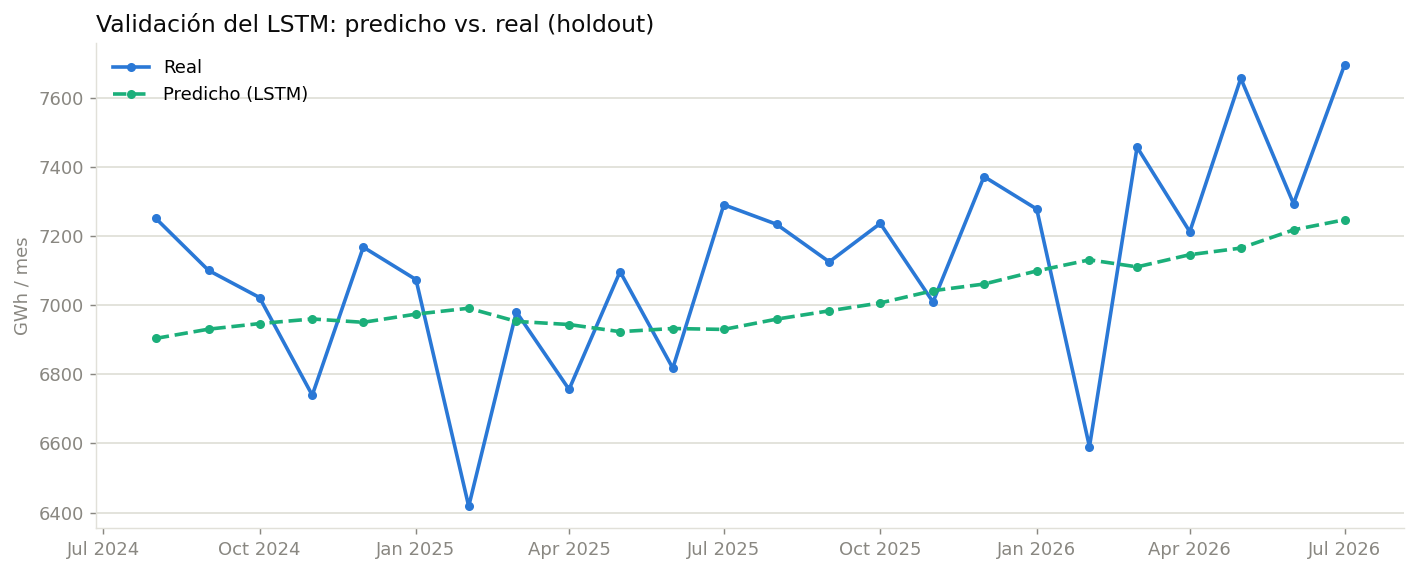

In [ ]:
fechas_test = serie.index[-TEST_SIZE:]

fig, ax = plt.subplots(figsize=(11, 4.5), dpi=130)
ax.plot(fechas_test, real_test, color=COLOR_HIST, linewidth=2, marker="o", markersize=4, label="Real")
ax.plot(fechas_test, pred_test, color=COLOR_TEST, linewidth=2, marker="o", markersize=4, linestyle="--", label="Predicho (LSTM)")

ax.set_title("Validación del LSTM: predicho vs. real (holdout)", color=COLOR_INK, fontsize=13, loc="left")
ax.set_ylabel("GWh / mes", color=COLOR_MUTED)
ax.grid(axis="y", color=COLOR_GRID, linewidth=1)
ax.spines[["top", "right"]].set_visible(False)
ax.spines["left"].set_color(COLOR_GRID)
ax.spines["bottom"].set_color(COLOR_GRID)
ax.tick_params(colors=COLOR_MUTED)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

## 8. Reentrenar con todo el histórico

El modelo de arriba se evaluó dejando los últimos 24 meses afuera. Para el pronóstico final conviene aprovechar también esos meses: se reentrena la misma arquitectura con todos los datos disponibles, usando el número de épocas que el *early stopping* encontró como razonable en el paso anterior (para no sobreajustar).

In [ ]:
modelo_final = construir_modelo(LOOK_BACK)
modelo_final.fit(X, y, epochs=epocas_optimas, batch_size=16, verbose=0)
print("Modelo final entrenado con todo el histórico disponible.")

Modelo final entrenado con todo el histórico disponible.


## 9. Pronóstico del mes siguiente (con incertidumbre vía Monte Carlo Dropout)

Un LSTM normal da un solo número, sin intervalo de confianza. Para aproximar uno, se hacen `N_SIMULACIONES_MC` pasadas hacia adelante **con el dropout activo** (en vez de apagado, como en una predicción normal) — cada pasada da un resultado ligeramente distinto, y la dispersión entre todas aproxima la incertidumbre del modelo. Es una técnica conocida (*MC Dropout*), no un intervalo estadístico exacto.

In [ ]:
def pronosticar_con_incertidumbre(modelo, serie, escalador, look_back, n_simulaciones=200):
    ultima_ventana = escalador.transform(serie.values[-look_back:].reshape(-1, 1)).flatten()
    entrada = ultima_ventana.reshape(1, look_back, 1)

    predicciones_escaladas = []
    for _ in range(n_simulaciones):
        # training=True mantiene el dropout activo -> Monte Carlo Dropout
        pred = modelo(entrada, training=True).numpy().flatten()[0]
        predicciones_escaladas.append(pred)

    predicciones_gwh = escalador.inverse_transform(
        np.array(predicciones_escaladas).reshape(-1, 1)
    ).flatten()

    media = float(np.mean(predicciones_gwh))
    li = float(np.percentile(predicciones_gwh, 2.5))
    ls = float(np.percentile(predicciones_gwh, 97.5))
    fecha_pronostico = serie.index[-1] + pd.DateOffset(months=1)

    return {"fecha": fecha_pronostico, "media": media, "li": li, "ls": ls, "muestras": predicciones_gwh}


pron = pronosticar_con_incertidumbre(modelo_final, serie, escalador, LOOK_BACK, N_SIMULACIONES_MC)
print("=== PRONÓSTICO MENSUAL (LSTM, incertidumbre vía Monte Carlo Dropout) ===")
print(f"Mes pronosticado: {pron['fecha'].strftime('%B %Y')}")
print(f"Generación total estimada: {pron['media']:.1f} GWh  (rango aprox. 95%: {pron['li']:.1f} - {pron['ls']:.1f})")

=== PRONÓSTICO MENSUAL (LSTM, incertidumbre vía Monte Carlo Dropout) ===
Mes pronosticado: August 2026
Generación total estimada: 7350.6 GWh  (rango aprox. 95%: 6870.9 - 7936.2)


## 10. Estimado para "la próxima semana"

**Recordatorio:** esto NO es un pronóstico semanal independiente — el dato de origen es mensual. Es el pronóstico del mes repartido proporcionalmente entre 7 días. Útil como referencia de magnitud, no como predicción fina día a día.

In [ ]:
def estimar_semana(pron: dict) -> dict:
    dias_mes = pron["fecha"].days_in_month
    gwh_semana = (pron["media"] / dias_mes) * 7
    li_semana = (pron["li"] / dias_mes) * 7
    ls_semana = (pron["ls"] / dias_mes) * 7
    return {"gwh": gwh_semana, "li": li_semana, "ls": ls_semana}


semana = estimar_semana(pron)
print("=== ESTIMADO SEMANAL (proporcional, NO es un modelo independiente) ===")
print(f"Generación estimada próximos 7 días: {semana['gwh']:.1f} GWh")
print(f"Rango aproximado: {semana['li']:.1f} - {semana['ls']:.1f} GWh")

=== ESTIMADO SEMANAL (proporcional, NO es un modelo independiente) ===
Generación estimada próximos 7 días: 1659.8 GWh
Rango aproximado: 1551.5 - 1792.0 GWh


## 11. Gráfico: histórico + pronóstico

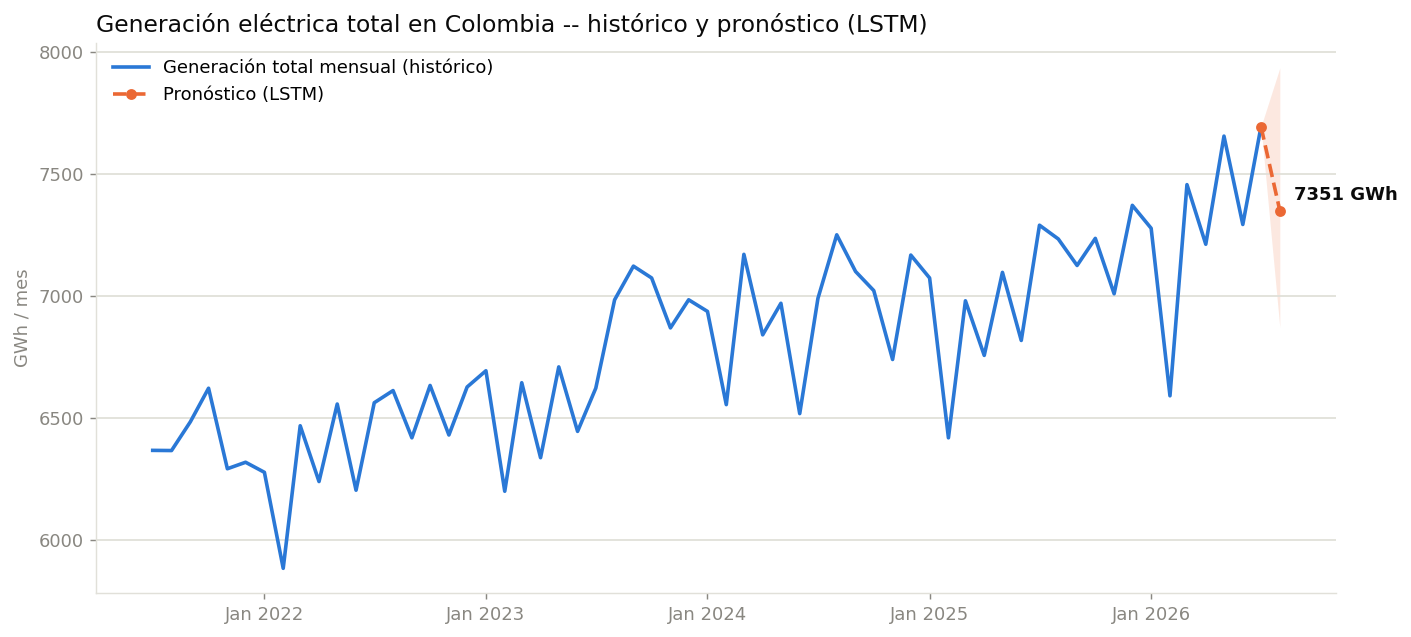

In [ ]:
corte = serie.index[-1] - pd.DateOffset(years=5)
serie_reciente = serie.loc[serie.index >= corte]

fig, ax = plt.subplots(figsize=(11, 5), dpi=130)

ax.plot(
    serie_reciente.index, serie_reciente.values,
    color=COLOR_HIST, linewidth=2, label="Generación total mensual (histórico)",
)
ax.plot(
    [serie.index[-1], pron["fecha"]], [serie.iloc[-1], pron["media"]],
    color=COLOR_FCST, linewidth=2, linestyle="--", marker="o", markersize=5,
    label="Pronóstico (LSTM)",
)
ax.fill_between(
    [serie.index[-1], pron["fecha"]], [serie.iloc[-1], pron["li"]], [serie.iloc[-1], pron["ls"]],
    color=COLOR_FCST, alpha=0.15, linewidth=0,
)
ax.annotate(
    f"{pron['media']:.0f} GWh",
    (pron["fecha"], pron["media"]),
    textcoords="offset points", xytext=(8, 6),
    color=COLOR_INK, fontsize=10, fontweight="bold",
)

ax.set_title(
    "Generación eléctrica total en Colombia -- histórico y pronóstico (LSTM)",
    color=COLOR_INK, fontsize=13, loc="left",
)
ax.set_ylabel("GWh / mes", color=COLOR_MUTED)
ax.grid(axis="y", color=COLOR_GRID, linewidth=1)
ax.spines[["top", "right"]].set_visible(False)
ax.spines["left"].set_color(COLOR_GRID)
ax.spines["bottom"].set_color(COLOR_GRID)
ax.tick_params(colors=COLOR_MUTED)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.savefig("pronostico_generacion_upme_lstm.png", dpi=150)
plt.show()

## Próximos pasos posibles

- Comparar este pronóstico contra el de la versión SARIMA (mismo dataset, modelo estadístico clásico) — con ~300 meses de datos, es una comparación que vale la pena antes de confiar en uno solo.
- Sacar un [App Token](https://www.datos.gov.co/profile/edit/developer_settings) si vas a correr esto seguido, para no compartir el límite de tasa anónimo.
- Sumar la [API de XM](https://github.com/EquipoAnaliticaXM/API_XM) para tener demanda/generación con granularidad diaria u horaria, y ahí sí entrenar un LSTM con una cantidad de datos más apropiada y construir un pronóstico semanal real.
- Probar otras arquitecturas (más capas, GRU, más `LOOK_BACK`) o ajustar `TEST_SIZE`/`N_SIMULACIONES_MC` según qué tan estable quieras el intervalo de incertidumbre.